# Data Exploratory

- Peak GCVI
- District yield
- Location: India, Season: Kharif

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import ee
import geemap
import rasterio as rio
import numpy as np
import geopandas as gpd
import seaborn as sns
import geopandas as gpd

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/Users/edliao/miniconda/envs/research/lib/python3.10/site-packages/google/api_core/_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.16) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


## GCVI

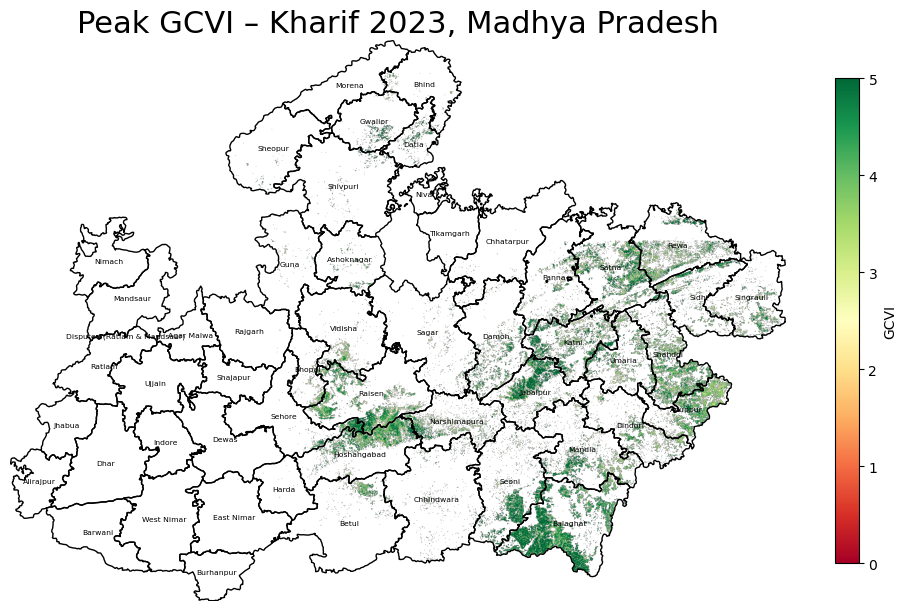

In [27]:
from rasterio.plot import show
import matplotlib.colors as mcolors

districts = gpd.read_file('../../data/MP_Districts_GAUL/MP_Districts_GAUL.shp')
districts = districts.to_crs('EPSG:4326')
fig, ax = plt.subplots(figsize=(10, 10))

with rio.open('../../data/gcvi/peak_gcvi_kharif_2022_mp_crop.tif') as src:
    show(src, ax=ax, cmap='RdYlGn', vmin=0, vmax=5)
    districts = districts.to_crs(src.crs)

districts.plot(ax=ax, color='none', edgecolor='black', linewidth=1)
ax.set_title('Peak GCVI – Kharif 2023, Madhya Pradesh', fontsize=22)

# District name labels
for _, row in districts.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(row['gaul2_name'], xy=(centroid.x, centroid.y),
                ha='center', va='center', fontsize=5.5, color='black')

# Colorbar
sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=mcolors.Normalize(vmin=0, vmax=5))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='GCVI', shrink=0.5)

plt.axis('off')
plt.tight_layout()
plt.show()

## 2024 Analysis — Rice Yield vs Peak GCVI

In [30]:
import os, tempfile
import rasterio
import numpy as np
import geopandas as gpd
from rasterstats import zonal_stats
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

# ── 1. Load district boundaries ───────────────────────────────────────
districts_2024 = gpd.read_file('../../data/MP_Districts_GAUL/MP_Districts_GAUL.shp').to_crs('EPSG:4326')
districts_2024['gaul2_name'] = districts_2024['gaul2_name'].str.strip().str.title()

# ── 2. Extract district-level mean GCVI from 2024 raw TIF ────────────
tif_path = '../../data/gcvi/peak_gcvi_kharif_2024_mp_crop.tif'

with rasterio.open(tif_path) as src:
    data    = src.read(1).astype(float)
    nodata  = src.nodata
    profile = src.profile

data[np.isinf(data)] = np.nan
if nodata is not None:
    data[data == nodata] = np.nan

with tempfile.NamedTemporaryFile(suffix='.tif', delete=False) as tmp:
    tmp_path = tmp.name
profile.update(dtype=rasterio.float32, nodata=np.nan)
with rasterio.open(tmp_path, 'w', **profile) as dst:
    dst.write(data.astype(np.float32), 1)

stats_gcvi = zonal_stats(districts_2024, tmp_path, stats=['mean'], nodata=np.nan)
os.unlink(tmp_path)

districts_2024['gcvi_mean_2024'] = [s['mean'] for s in stats_gcvi]
print(f"GCVI extracted for {districts_2024['gcvi_mean_2024'].notna().sum()} districts")
districts_2024[['gaul2_name', 'gcvi_mean_2024']]

GCVI extracted for 39 districts


,gaul2_name,gcvi_mean_2024
0,Agar Malwa,NaN
1,Alirajpur,NaN
2,Anuppur,5.148458
3,Ashoknagar,6.162149
4,Balaghat,4.737838
5,Barwani,NaN
6,Betul,3.922689
7,Bhind,4.610319
8,Bhopal,3.640808
9,Burhanpur,4.634648


# Visualize the peak gcvi on the map


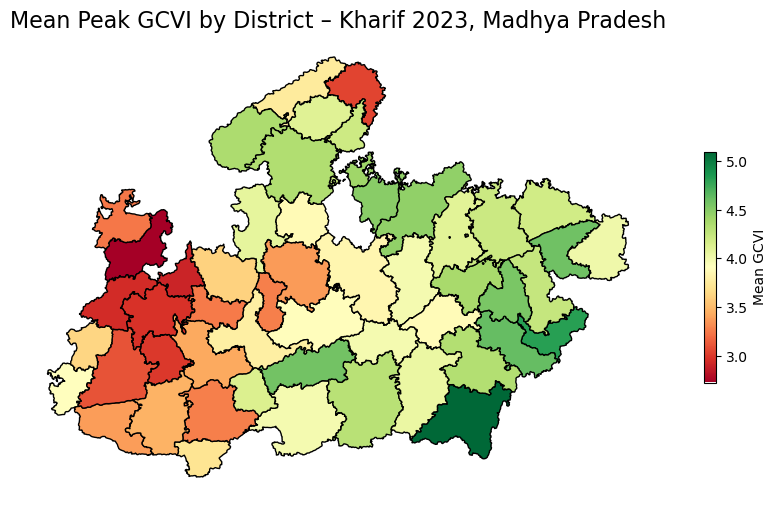

In [26]:
fig, ax = plt.subplots(figsize=(12, 6))
districts_2024.plot(column='gcvi_mean_2024', cmap='RdYlGn', edgecolor='black',
                    ax=ax, legend=True,
                    legend_kwds={'shrink': 0.5, 'label': 'Mean GCVI'})
ax.set_title('Mean Peak GCVI by District – Kharif 2023, Madhya Pradesh', fontsize=16)
ax.axis('off')
plt.show()

In [4]:
# ── 3. Load 2024-25 rice yield ────────────────────────────────────────
df_2024 = pd.read_csv('../../data/yield/DES-District-Data-For-2022-23-to-2024-25.csv',
                      encoding='utf-8-sig')

rice_2024 = df_2024[
    (df_2024['State']  == 'Madhya Pradesh') &
    (df_2024['Season'] == 'Kharif') &
    (df_2024['Crop']   == 'Rice')
][['District', 'Yield-2024-25']].copy()

rice_2024.columns      = ['District', 'rice_yield_kg_ha']
rice_2024['rice_yield_kg_ha'] = pd.to_numeric(rice_2024['rice_yield_kg_ha'], errors='coerce')

# Apply same name fixes as before
name_mapping = {
    'Narsimhapur':           'Narshimapura',
    'Khargone (West Nimar)': 'West Nimar',
    'Khandwa (East Nimar)':  'East Nimar',
    'Narmadapuram':          'Hoshangabad',
    'Niwari':                'Nivari',
    'Neemuch':               'Nimach',
    'Agar-Malwa':            'Agar Malwa',
}
rice_2024['District'] = rice_2024['District'].str.strip().str.title().replace(name_mapping)

print(f"Rice yield districts: {len(rice_2024)}")
rice_2024.head()

Rice yield districts: 55


,District,rice_yield_kg_ha
12034,Agar Malwa,1736.0
12076,Alirajpur,1118.0
12120,Anuppur,1854.0
12166,Ashoknagar,2355.0
12206,Balaghat,2123.0


In [5]:
# ── 4. Merge GCVI + yield ─────────────────────────────────────────────
merged_2024 = districts_2024[['gaul2_name', 'gcvi_mean_2024', 'geometry']].merge(
    rice_2024, left_on='gaul2_name', right_on='District', how='inner'
).dropna(subset=['gcvi_mean_2024', 'rice_yield_kg_ha'])

print(f"Matched districts: {len(merged_2024)}")
merged_2024[['gaul2_name', 'gcvi_mean_2024', 'rice_yield_kg_ha']].head(10)

Matched districts: 52


,gaul2_name,gcvi_mean_2024,rice_yield_kg_ha
0,Agar Malwa,2.903346,1736.0
1,Alirajpur,3.910678,1118.0
2,Anuppur,4.815132,1854.0
3,Ashoknagar,3.874146,2355.0
4,Balaghat,5.099382,2123.0
5,Barwani,3.375136,683.0
6,Betul,3.978266,2506.0
7,Bhind,3.046552,3031.0
8,Bhopal,3.265366,2563.0
9,Burhanpur,3.711868,1266.0


Pearson r = 0.474   p = 0.0004   n = 52


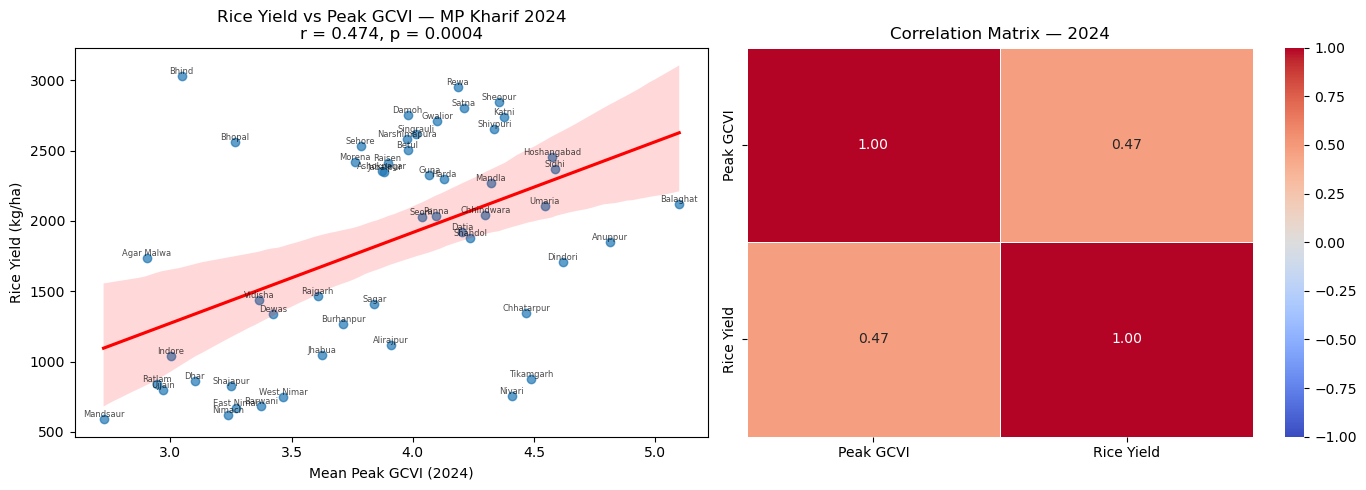

In [6]:
# ── 5. Pearson correlation ────────────────────────────────────────────
r, p = stats.pearsonr(merged_2024['gcvi_mean_2024'], merged_2024['rice_yield_kg_ha'])
print(f"Pearson r = {r:.3f}   p = {p:.4f}   n = {len(merged_2024)}")

# ── 6. Scatter + regression + correlation heatmap ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter with regression line
sns.regplot(data=merged_2024, x='gcvi_mean_2024', y='rice_yield_kg_ha',
            ax=axes[0], scatter_kws={'alpha': 0.7}, line_kws={'color': 'red'})

# Label each point with district name
for _, row in merged_2024.iterrows():
    axes[0].annotate(row['gaul2_name'],
                     xy=(row['gcvi_mean_2024'], row['rice_yield_kg_ha']),
                     fontsize=6, alpha=0.7, ha='center', va='bottom')

axes[0].set_title(f'Rice Yield vs Peak GCVI — MP Kharif 2024\nr = {r:.3f}, p = {p:.4f}', fontsize=12)
axes[0].set_xlabel('Mean Peak GCVI (2024)')
axes[0].set_ylabel('Rice Yield (kg/ha)')

# Correlation heatmap
corr_df = merged_2024[['gcvi_mean_2024', 'rice_yield_kg_ha']].corr()
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            ax=axes[1], linewidths=0.5,
            xticklabels=['Peak GCVI', 'Rice Yield'],
            yticklabels=['Peak GCVI', 'Rice Yield'])
axes[1].set_title('Correlation Matrix — 2024')

plt.tight_layout()
plt.show()